In [1]:
import os
import random
import tarfile
import urllib.request
from pathlib import Path
import math
from collections import defaultdict
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
data_dir = Path("./")
data_dir.mkdir(parents=True,exist_ok=True)

In [5]:
url = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
tar_path = data_dir/ "imagenette2-320.tgz"
extract_path = data_dir/"imagenette2-320"


if not extract_path.exists():

  print("Downloading ImageNette")

  urllib.request.urlretrieve(url, tar_path)

  print("Extracting")

  with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(data_dir)



print(extract_path)
print(extract_path/"train")


Extracting


/tmp/ipykernel_894/3503413017.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


imagenette2-320
imagenette2-320/train


In [6]:
image_size = 256

# Resizing images to 256X256 and normalizing it to [-1,1].
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [7]:
train_data = extract_path / "train"
full_dataset = datasets.ImageFolder(root=train_data, transform = transform)

print("Total Images:", len(full_dataset))
print("Classes:", full_dataset.classes)

Total Images: 9469
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


# Three Training Examples Overfit


In [8]:
# Selecting 3 Images

selected_images = []
selected_labels = []
seen_classes = set()

for img, label in full_dataset:

  if label not in seen_classes:
    selected_images.append(img)
    selected_labels.append(label)
    seen_classes.add(label)

  if len(selected_images) == 3:
    break


selected_images = torch.stack(selected_images, dim=0)
selected_labels = torch.tensor(selected_labels)

print("Selected Images Shapes: ", selected_images.shape)
print("Selected Labels: ", selected_labels.tolist())
print("Selected Class Names: ", [full_dataset.classes[i] for i in selected_labels.tolist()] )

Selected Images Shapes:  torch.Size([3, 3, 256, 256])
Selected Labels:  [0, 1, 2]
Selected Class Names:  ['n01440764', 'n02102040', 'n02979186']


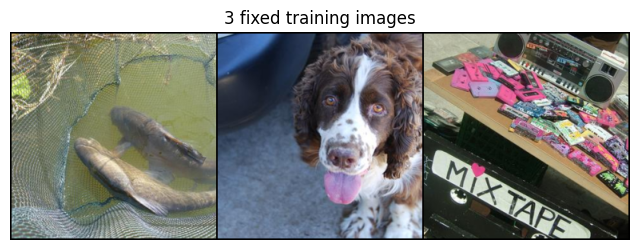

In [9]:
def denorm(x):
    return (x + 1) / 2

grid = make_grid(denorm(selected_images).clamp(0, 1), nrow=3)

plt.figure(figsize=(8, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("3 fixed training images")
plt.show()

In [10]:
class ImageDataset(Dataset):
    def __init__(self, images, labels=None):
        self.images = images
        self.labels = labels

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        if self.labels is None:
            return self.images[idx]
        return self.images[idx], self.labels[idx]


In [11]:
three_image_dataset = ImageDataset(selected_images, selected_labels)
three_image_dataloader = DataLoader(three_image_dataset, batch_size=3, shuffle=True, drop_last=True)

In [12]:
batch = next(iter(three_image_dataloader))
X,y = batch

print("X: ", X.shape)
print("y: ", y)

X:  torch.Size([3, 3, 256, 256])
y:  tensor([1, 2, 0])


In [13]:
# MeanFlow Data Construction

x = selected_images.to(device) # Real Images
B = x.shape[0]
eps = torch.randn_like(x) # Gaussian Noise

t = torch.rand(B, device=device)
r = torch.rand(B, device=device)

# Making sure r<=t
t_final = torch.maximum(t,r)
r_final = torch.minimum(t,r)

t_img = t_final[:, None, None, None] # Because our x shape would be [Batch_size, Channels,Height,Width]

z_t = (1-t_img) * x + t_img * eps # Interpolated Sample

v = eps - x # Conditional Velocity

print("x:", x.shape)
print("eps:", eps.shape)
print("z_t:", z_t.shape)
print("v:", v.shape)
print("r:", r_final)
print("t:", t_final)

x: torch.Size([3, 3, 256, 256])
eps: torch.Size([3, 3, 256, 256])
z_t: torch.Size([3, 3, 256, 256])
v: torch.Size([3, 3, 256, 256])
r: tensor([0.3148, 0.3071, 0.0706], device='cuda:0')
t: tensor([0.3264, 0.9967, 0.6121], device='cuda:0')


In [14]:
print(x.min(), x.max())
print(eps.mean(), eps.std())
print(z_t.min(), z_t.max())

tensor(-0.9922, device='cuda:0') tensor(1., device='cuda:0')
tensor(0.0009, device='cuda:0') tensor(0.9988, device='cuda:0')
tensor(-4.4745, device='cuda:0') tensor(4.3822, device='cuda:0')


In [15]:
def add_coord_channels(z):
    B, C, H, W = z.shape
    device = z.device
    dtype = z.dtype

    y_coords = torch.linspace(-1, 1, H, device=device, dtype=dtype)
    x_coords = torch.linspace(-1, 1, W, device=device, dtype=dtype)

    yy, xx = torch.meshgrid(y_coords, x_coords, indexing="ij")

    xx = xx[None, None, :, :].expand(B, 1, H, W)
    yy = yy[None, None, :, :].expand(B, 1, H, W)

    return torch.cat([z, xx, yy], dim=1)

In [16]:
# Make a Sinusoidal Embedding because a neural network doesn't learn very rich patterns from a single scalar t.

class SinusoidalEmbedding(nn.Module):

  def __init__(self, dim: int):
    super().__init__()
    self.dim = dim

  def forward(self, x):

    half_dim = self.dim // 2 # Half sin wave and half cos wave
    device = x.device

    freqs = torch.exp(
        -math.log(1000) * torch.arange(half_dim, device=device) / (half_dim - 1)
    ) # Forms frequency something like positional encoding

    args = x[:, None] * freqs[None, :] # Multiply each time value with each frequency to create sinusoidal inputs

    emb = torch.cat([torch.sin(args), torch.cos(args)], dim = -1)

    if self.dim % 2 == 1:
      emb = F.pad(emb, (0,1)) # In case embedding dim is not divisible by 2, we will add an extra pad

    return emb



In [17]:
emb_layer = SinusoidalEmbedding(dim=8)
times = torch.tensor([0.0,0.5,1.0])
emb = emb_layer(times)

print("Times Shape: ", times.shape)
print("Embedding Shape: ", emb.shape)
print(emb)

Times Shape:  torch.Size([3])
Embedding Shape:  torch.Size([3, 8])
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00],
        [4.7943e-01, 4.9979e-02, 5.0000e-03, 5.0000e-04, 8.7758e-01, 9.9875e-01,
         9.9999e-01, 1.0000e+00],
        [8.4147e-01, 9.9833e-02, 9.9998e-03, 1.0000e-03, 5.4030e-01, 9.9500e-01,
         9.9995e-01, 1.0000e+00]])


In [18]:
class ResBlock(nn.Module):

    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, temb):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)


        time_bias = self.time_proj(temb)[:, :, None, None]
        h = h + time_bias

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.skip(x)

In [19]:
class MeanFlowUNet(nn.Module):

    def __init__(
        self,
        img_channels=3,
        base_channels=64,
        time_emb_dim=128,
        num_classes=3,
    ):
        super().__init__()

        self.time_embed = SinusoidalEmbedding(time_emb_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim*2, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )

        self.label_embed = nn.Embedding(num_classes, time_emb_dim)

        self.in_conv = nn.Conv2d(img_channels + 2, base_channels, kernel_size=3, padding=1)

        self.res1 = ResBlock(base_channels, base_channels, time_emb_dim)
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)

        self.res2 = ResBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)

        self.mid = ResBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.res_up1 = ResBlock(base_channels * 2, base_channels * 2, time_emb_dim)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.res_up2 = ResBlock(base_channels, base_channels, time_emb_dim)

        self.out_norm = nn.GroupNorm(8, base_channels)
        self.out_conv = nn.Conv2d(base_channels, img_channels, kernel_size=3, padding=1)

    def forward(self, z, r, t, y=None):

        dt = t - r

        #t_emb = t
        #dt_emb = dt

        t_emb = self.time_embed(t)
        dt_emb = self.time_embed(dt)


        #temb = torch.stack([t, dt], dim=1)  # [B, 2]
        temb = torch.cat([t_emb, dt_emb], dim=-1)
        temb = self.time_mlp(temb)

        if y is not None:
            temb = temb + self.label_embed(y)

        z = add_coord_channels(z)
        h1 = self.in_conv(z)
        h1 = self.res1(h1, temb)

        h2 = self.down1(h1)
        h2 = self.res2(h2, temb)

        h3 = self.down2(h2)
        h3 = self.mid(h3, temb)

        h = self.up1(h3)
        h = h + h2
        h = self.res_up1(h, temb)

        h = self.up2(h)
        h = h + h1
        h = self.res_up2(h, temb)

        h = self.out_norm(h)
        h = F.silu(h)
        out = self.out_conv(h)

        return out

In [20]:
model = MeanFlowUNet(
    img_channels=3,
    base_channels=64,
    time_emb_dim=128,
    num_classes=3,
).to(device)

# Single example
B = 1
z = torch.randn(B, 3, 256, 256).to(device)

r = torch.tensor([0.2], device=device)
t = torch.tensor([0.7], device=device)

y = torch.tensor([0], dtype=torch.long, device=device)

out = model(z, r, t, y)

print("z shape:", z.shape)
print("r shape:", r.shape)
print("t shape:", t.shape)
print("output shape:", out.shape)

z shape: torch.Size([1, 3, 256, 256])
r shape: torch.Size([1])
t shape: torch.Size([1])
output shape: torch.Size([1, 3, 256, 256])


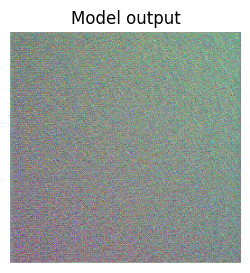

In [21]:
out_img = out[0].detach().cpu()
out_img = out_img.permute(1, 2, 0)

# Normalize for visualization only
out_img = (out_img - out_img.min()) / (out_img.max() - out_img.min())

plt.figure(figsize=(3, 3))
plt.imshow(out_img)
plt.axis("off")
plt.title("Model output")
plt.show()

In [22]:
def sample_r_t(batch_size, device, same_time_prob=0.4):
    a = torch.rand(batch_size, device=device)
    b = torch.rand(batch_size, device=device)

    t = torch.maximum(a, b)
    r = torch.minimum(a, b)

    # Some samples use r = t.
    # This reduces to normal flow matching and stabilizes training.
    same_mask = torch.rand(batch_size, device=device) < same_time_prob
    r = torch.where(same_mask, t, r)

    return r, t

In [23]:
def meanflow_loss(
    model,
    x,
    y=None,
    same_time_prob=0.4,
):
    B = x.shape[0]
    device = x.device

    # Noise endpoint
    eps = torch.randn_like(x)

    # Sample r <= t
    r, t = sample_r_t(
        B,
        device=device,
        same_time_prob=same_time_prob,
    )

    # Interpolation path:
    # t = 0 -> real image x
    # t = 1 -> noise eps
    t_img = t[:, None, None, None]
    z_t = (1.0 - t_img) * x + t_img * eps

    # Instantaneous velocity along the linear path
    v = eps - x

    def fn(z_in, r_in, t_in):
        return model(z_in, r_in, t_in, y)

    # JVP: derivative of u(z_t, r, t) along the flow direction
    u, dudt = torch.func.jvp(
        fn,
        (z_t, r, t),
        (v, torch.zeros_like(r), torch.ones_like(t)),
    )

    # MeanFlow identity target
    dt = (t - r)[:, None, None, None]
    u_tgt = v - dt * dudt

    # Pure MeanFlow loss
    loss = ((u - u_tgt.detach()) ** 2).mean()

    return loss, loss.detach()

In [24]:
'''
x_batch = selected_images.to(device)
y_batch = torch.arange(x_batch.shape[0], device=device)

loss = meanflow_loss(model, x_batch, y_batch)

print("loss:", loss.item())

loss.backward()

total_grad_norm = 0.0
for p in model.parameters():
    if p.grad is not None:
        total_grad_norm += p.grad.norm().item()

print("grad norm:", total_grad_norm)
'''

'\nx_batch = selected_images.to(device)\ny_batch = torch.arange(x_batch.shape[0], device=device)\n\nloss = meanflow_loss(model, x_batch, y_batch)\n\nprint("loss:", loss.item())\n\nloss.backward()\n\ntotal_grad_norm = 0.0\nfor p in model.parameters():\n    if p.grad is not None:\n        total_grad_norm += p.grad.norm().item()\n\nprint("grad norm:", total_grad_norm)\n'

In [26]:
model = MeanFlowUNet(
    img_channels=3,
    base_channels=64,
    time_emb_dim=128,
    num_classes=3,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.0,
)

num_epochs = 20000

step_loss_history = []
epoch_loss_history = []

model.train()

pbar = tqdm(range(num_epochs))

for epoch in pbar:
    epoch_losses = []

    for x, y in three_image_dataloader:
        x = x.to(device)
        y = y.to(device)

        loss, mf_loss = meanflow_loss(model, x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)

        optimizer.step()

        step_loss_history.append(loss.item())
        epoch_losses.append(loss.item())

    avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)
    epoch_loss_history.append(avg_epoch_loss)

    if epoch % 100 == 0:
        pbar.set_description(
            f"epoch={epoch} loss={avg_epoch_loss:.6f} mf={mf_loss:.6f}"
        )

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:04d} | "
            f"Loss: {avg_epoch_loss:.6f} | "
            f"MF: {mf_loss:.6f}"
        )

epoch=0 loss=1.248603 mf=1.248603:   0%|          | 1/20000 [00:01<8:51:44,  1.60s/it]

Epoch 0000 | Loss: 1.248603 | MF: 1.248603


epoch=500 loss=0.105022 mf=0.105022:   3%|▎         | 501/20000 [04:05<2:41:23,  2.01it/s]

Epoch 0500 | Loss: 0.105022 | MF: 0.105022


epoch=1000 loss=0.101845 mf=0.101845:   5%|▌         | 1001/20000 [08:15<2:39:09,  1.99it/s]

...

epoch=19000 loss=0.047368 mf=0.047368:  95%|█████████▌| 19001/20000 [2:37:47<08:20,  2.00it/s]

Epoch 19000 | Loss: 0.047368 | MF: 0.047368


epoch=19500 loss=0.839319 mf=0.839319:  98%|█████████▊| 19501/20000 [2:41:56<04:07,  2.01it/s]

Epoch 19500 | Loss: 0.839319 | MF: 0.839319


epoch=19900 loss=0.045640 mf=0.045640: 100%|██████████| 20000/20000 [2:46:05<00:00,  2.01it/s]


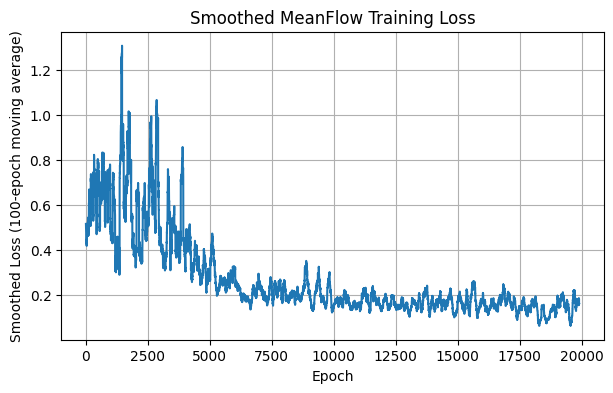

In [27]:
import numpy as np
import matplotlib.pyplot as plt

window = 100

loss_arr = np.array(epoch_loss_history)

if len(loss_arr) >= window:
    smooth_loss = np.convolve(loss_arr, np.ones(window) / window, mode="valid")

    plt.figure(figsize=(7, 4))
    plt.plot(smooth_loss)
    plt.xlabel("Epoch")
    plt.ylabel(f"Smoothed Loss ({window}-epoch moving average)")
    plt.title("Smoothed MeanFlow Training Loss")
    plt.grid(True)
    plt.show()

In [28]:
def denormalize_img(x):

    x = (x + 1) / 2
    return x.clamp(0, 1)

In [29]:
@torch.no_grad()
def generate_meanflow_samples(model, sample_shape, device, y=None):
    model.eval()

    z = torch.randn(sample_shape, device=device)

    B = sample_shape[0]
    t = torch.ones(B, device=device)
    r = torch.zeros(B, device=device)

    u = model(z, r, t, y)

    x_gen = z - u

    return x_gen.clamp(-1, 1)

In [30]:
x_orig, y_orig = next(iter(three_image_dataloader))
x_orig = x_orig.to(device)
y_orig = y_orig.to(device)

x_gen = generate_meanflow_samples(
    model=model,
    sample_shape=x_orig.shape,
    device=device,
    y=y_orig,
)

print("Original shape:", x_orig.shape)
print("Generated shape:", x_gen.shape)

assert x_orig.shape[-2:] == (256, 256)
assert x_gen.shape == x_orig.shape

Original shape: torch.Size([3, 3, 256, 256])
Generated shape: torch.Size([3, 3, 256, 256])


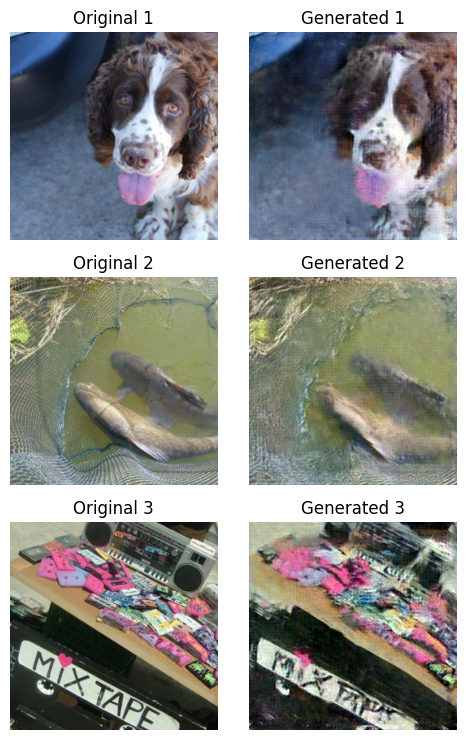

In [31]:
num_samples=3
fig, axes = plt.subplots(num_samples, 2, figsize=(5, 2.5 * num_samples))

for i in range(num_samples):
    orig_img = denormalize_img(x_orig[i].detach().cpu()).permute(1, 2, 0)
    gen_img = denormalize_img(x_gen[i].detach().cpu()).permute(1, 2, 0)

    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gen_img)
    axes[i, 1].set_title(f"Generated {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()